## **1. Import Library**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

import joblib

## **2. Load Dataset**

In [2]:
df = pd.read_csv("/content/data_clustering_inverse (1).csv")

In [3]:
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,0
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,2
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,1
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,2
4,13.45,2023-10-16 17:51:24,Credit,Atlanta,Online,45.0,Student,198.0,1.0,7429.40,2024-11-04 08:06:39,2


In [4]:
df.isnull().sum()

,0
TransactionAmount,0
TransactionDate,2
TransactionType,2
Location,2
Channel,2
CustomerAge,0
CustomerOccupation,2
TransactionDuration,0
LoginAttempts,0
AccountBalance,0


##**3. Preprocessing Data**

### Drop Irrelevant Data

In [5]:
df.drop(["TransactionDate", "PreviousTransactionDate"], axis = 1,inplace=True, errors='ignore')
print("Penghapusan fitur berhasil")
print("\nFitur tersisa:")
df.columns.to_list()

Penghapusan fitur berhasil

Fitur tersisa:


['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'Target']

### Encoder Categorical Data

In [6]:
encoders = {}
encode_df = pd.DataFrame()

categorical_df = df.select_dtypes(include=['object', 'category'])

# Encode kolom kategorikal
for kolom in categorical_df.columns:
    df[kolom] = df[kolom].astype(str).str.strip()   # hapus spasi
    df[kolom].replace(['', ' ', 'nan', 'None', 'NaN'], np.nan, inplace=True)

    if df[kolom].isnull().sum() > 0:
        mode_val = df[kolom].mode()[0]
        df[kolom].fillna(mode_val, inplace=True)

    label_encoder = LabelEncoder()
    encode_df[kolom] = label_encoder.fit_transform(df[kolom])
    encoders[kolom] = label_encoder

df[categorical_df.columns] = encode_df
df.head()

/tmp/ipykernel_1800/2761469834.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[kolom].replace(['', ' ', 'nan', 'None', 'NaN'], np.nan, inplace=True)
/tmp/ipykernel_1800/2761469834.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Target
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21,0
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91,2
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35,1
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06,2
4,13.45,0,1,2,45.0,3,198.0,1.0,7429.40,2


## **4. Data Splitting**


In [7]:
X = df.drop(columns=['Target'])
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(2011, 9), y_train=(2011,)
Test set shape: X_test=(503, 9), y_test=(503,)


## **5. Build Classification Model**

### Decision Tree

In [8]:
dt = DecisionTreeClassifier().fit(X_train, y_train)

joblib.dump(dt, 'decision_tree_model.h5')

['decision_tree_model.h5']

### Random Forest

In [9]:
rf = RandomForestClassifier().fit(X_train, y_train)

joblib.dump(rf, 'explore_RandomForest_classification.h5')

['explore_RandomForest_classification.h5']

### Support Vector Machine

In [10]:
svm = SVC().fit(X_train, y_train)

joblib.dump(svm, 'explore_SupportVectorMachine_classification.h5')

['explore_SupportVectorMachine_classification.h5']

### K-Nearest Neighbor

In [11]:
knn = KNeighborsClassifier().fit(X_train, y_train)

joblib.dump(knn, 'explore_KNearestNeighbor_classification.h5')

['explore_KNearestNeighbor_classification.h5']

## **6. Models Evaluation**


=== K-Nearest Neighbors (KNN) ===
Accuracy : 0.748
Precision: 0.747
Recall   : 0.748
F1-Score : 0.747


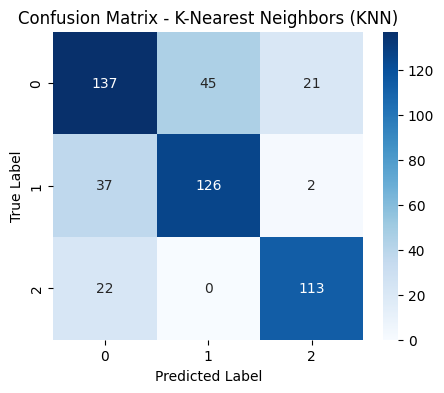


=== Decision Tree (DT) ===
Accuracy : 0.982
Precision: 0.982
Recall   : 0.982
F1-Score : 0.982


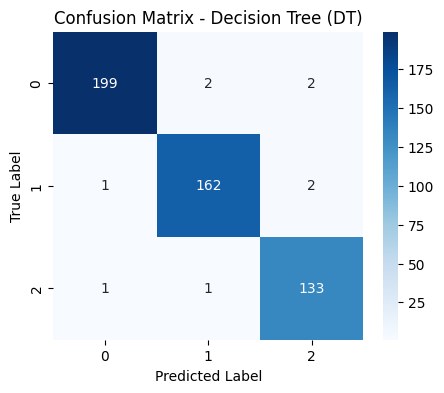


=== Random Forest (RF) ===
Accuracy : 0.976
Precision: 0.976
Recall   : 0.976
F1-Score : 0.976


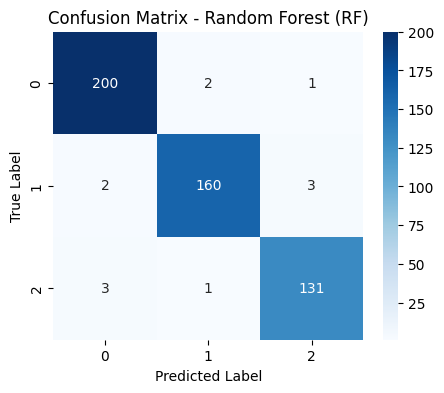


=== Support Vector Machine (SVM) ===
Accuracy : 0.746
Precision: 0.745
Recall   : 0.746
F1-Score : 0.745


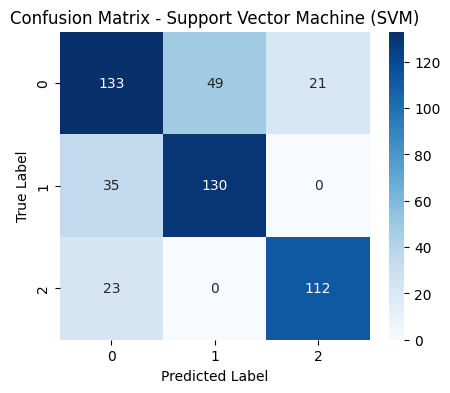

In [12]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    results = {
        'Confusion Matrix': cm,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    }
    return results

results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)': evaluate_model(dt, X_test, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
}


# ===== Tampilkan hasil per model =====
for model_name, metrics in results.items():
    print(f"\n=== {model_name} ===")
    print(f"Accuracy : {metrics['Accuracy']:.3f}")
    print(f"Precision: {metrics['Precision']:.3f}")
    print(f"Recall   : {metrics['Recall']:.3f}")
    print(f"F1-Score : {metrics['F1-Score']:.3f}")

    # Confusion matrix
    cm = metrics['Confusion Matrix']
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


## **7. Hyperparameter Tuning for KNN Model**

In [13]:
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # p=1: manhattan, p=2: euclidean
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

knn_tuned = grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Fitting 5 folds for each of 84 candidates, totalling 420 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
Best Score: 0.7881695739663963


### Hyperparameter Tuning Evaluation


🎯 BEST KNN MODEL RESULTS
Best Parameters:
   metric: manhattan
   n_neighbors: 15
   p: 1
   weights: distance

Best Cross-Validation Accuracy: 0.7882

=== Evaluation on Test Set ===
Accuracy : 0.7893
Precision: 0.7882
Recall   : 0.7893
F1-Score : 0.7886


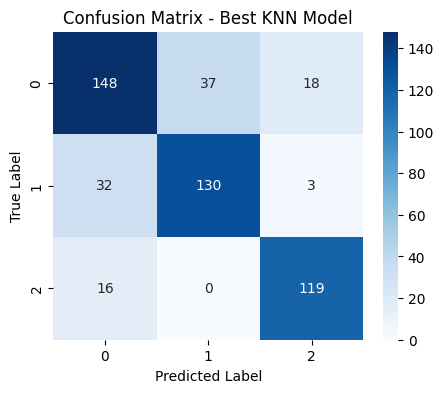

In [14]:
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_knn = grid_search.best_estimator_

print("\n" + "="*60)
print("🎯 BEST KNN MODEL RESULTS")
print("="*60)
print("Best Parameters:")
for param, value in best_params.items():
    print(f"   {param}: {value}")

print(f"\nBest Cross-Validation Accuracy: {best_score:.4f}")

# Evaluasi di test set
y_pred = best_knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n=== Evaluation on Test Set ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Best KNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [15]:
# Menyimpan Model hasil tuning
joblib.dump(knn_tuned, 'tuning_classification.h5')

['tuning_classification.h5']

End of Code